In [ ]:
# Employee Attrition Prediction using Machine Learning

## Internship Project – Week 2

### Submitted By
**Name:** Dhanush Gundu

### Organization
**XYlofy AI – Internship & Training Program**

---

## Project Overview

Employee attrition is one of the biggest challenges faced by organizations. Losing experienced employees results in increased recruitment costs, training expenses, reduced productivity, and loss of organizational knowledge. Predicting employee attrition enables Human Resource (HR) teams to proactively identify employees who may be at risk of leaving and implement effective retention strategies.

In this project, a Machine Learning pipeline is developed using the IBM HR Analytics Employee Attrition dataset. The workflow includes data exploration, preprocessing, exploratory data analysis, model development, evaluation, and business recommendations. Three classification models are compared to identify the most effective approach for predicting employee attrition while providing actionable insights for HR decision-makers.

In [ ]:
# Problem Statement

Every company loses employees, but losing skilled employees at the wrong time leads to significant costs in recruitment, training, and productivity. HR teams aim to identify employees who are likely to leave before attrition occurs so that preventive actions can be taken.

The objective of this project is to develop a Machine Learning model capable of predicting employee attrition based on factors such as job satisfaction, monthly income, work-life balance, years at the company, overtime, and performance ratings. The resulting insights will help HR departments make informed decisions to improve employee retention.

In [ ]:
# Objectives

The primary objectives of this project are:

- Load and explore the IBM HR Analytics dataset.
- Perform data cleaning and preprocessing.
- Analyze employee attrition through Exploratory Data Analysis (EDA).
- Build multiple Machine Learning classification models.
- Compare model performance using appropriate evaluation metrics.
- Identify the key factors contributing to employee attrition.
- Provide practical HR recommendations based on the findings.

# Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, machine learning model development, and evaluation.

In [3]:
# ============================
# Import Required Libraries
# ============================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# Task 1 – Data Loading & Exploration 

In this section, the IBM HR Analytics Employee Attrition dataset is loaded and explored to understand its structure, target variable, and feature types before preprocessing.

In [7]:
# Load Dataset 
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv") 
print("Dataset Loaded Successfully!") 
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (1470, 35)


In [8]:
# Display first 10 records 
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [9]:
# Dataset information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
# =====================================
# Target Variable & Attrition Analysis
# =====================================

# Target Variable
print("Target Variable:", "Attrition")

# Count employees who stayed vs left
attrition_counts = df["Attrition"].value_counts()

print("\nEmployee Attrition Counts:")
print(attrition_counts)

# Calculate attrition rate
attrition_rate = (attrition_counts["Yes"] / len(df)) * 100

print(f"\nOverall Attrition Rate: {attrition_rate:.2f}%")

Target Variable: Attrition

Employee Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall Attrition Rate: 16.12%


In [11]:
# =====================================
# Attrition Summary Table
# =====================================

attrition_summary = pd.DataFrame({
    "Count": df["Attrition"].value_counts(),
    "Percentage (%)": round(df["Attrition"].value_counts(normalize=True) * 100, 2)
})

attrition_summary

,Count,Percentage (%)
Attrition,,
No,1233,83.88
Yes,237,16.12


In [12]:
# =====================================
# Numerical vs Categorical Features
# =====================================

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Display the counts
print(f"Number of Numerical Features   : {len(numerical_cols)}")
print(f"Number of Categorical Features : {len(categorical_cols)}")

# Display the feature names
print("\nNumerical Features:")
print(list(numerical_cols))

print("\nCategorical Features:")
print(list(categorical_cols))

Number of Numerical Features   : 26
Number of Categorical Features : 9

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


## Observation

- The dataset contains **26 numerical features** and **9 categorical features**.
- Numerical features include variables such as Age, MonthlyIncome, TotalWorkingYears, and YearsAtCompany.
- Categorical features include Department, JobRole, BusinessTravel, MaritalStatus, and Attrition.
- The categorical features will be converted into numerical values using **One-Hot Encoding** before training the machine learning models.

# Task 2 – Data Cleaning & Preprocessing

In this section, the dataset is prepared for machine learning by checking for missing values, removing irrelevant features, encoding categorical variables, and scaling numerical features. Proper preprocessing ensures that the models learn effectively from clean and meaningful data.

In [13]:
# ===============================
# Check Missing Values
# ===============================

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

## Observation

- The IBM HR Analytics dataset contains **no missing values**.
- Therefore, no imputation techniques are required before model training.

In [15]:
# ===============================
# Check Duplicate Records
# ===============================

duplicates = df.duplicated().sum()

print(f"Number of Duplicate Records: {duplicates}")

Number of Duplicate Records: 0


## Observation

- The dataset contains **no duplicate records**.
- Therefore, duplicate removal is not required.

In [17]:
# ===============================
# Drop Irrelevant Columns
# ===============================

columns_to_drop = [
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print("Remaining Columns:", df.shape[1])

Remaining Columns: 32


## Observation

The following columns were removed:

- **EmployeeNumber** – Unique identifier; does not help prediction.
- **Over18** – Constant value ("Y") for all employees.
- **StandardHours** – Constant value (80) for all employees.

Removing irrelevant features helps reduce noise and improves model efficiency.

In [19]:
# ===============================
# Encode Target Variable
# ===============================

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [20]:
# ===============================
# Split Features and Target
# ===============================

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1470, 31)
Target Shape : (1470,)


In [21]:
# ===============================
# Identify Categorical Columns
# ===============================

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [22]:
# ===============================
# One-Hot Encoding
# ===============================

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after Encoding:", X.shape)

Shape after Encoding: (1470, 45)


In [23]:
# ===============================
# Feature Scaling
# ===============================

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


## Task 2 Summary

The preprocessing phase has been successfully completed.

The following steps were performed:

- Checked for missing values.
- Verified duplicate records.
- Removed irrelevant columns.
- Converted the target variable into binary format.
- Applied One-Hot Encoding to categorical variables.
- Standardized numerical features using StandardScaler.

The dataset is now ready for exploratory data analysis and machine learning model development.

# Task 3 – Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps identify trends, relationships, and patterns in employee attrition. The visualizations in this section provide insights into which employee groups are more likely to leave the company and help HR teams make informed retention decisions.

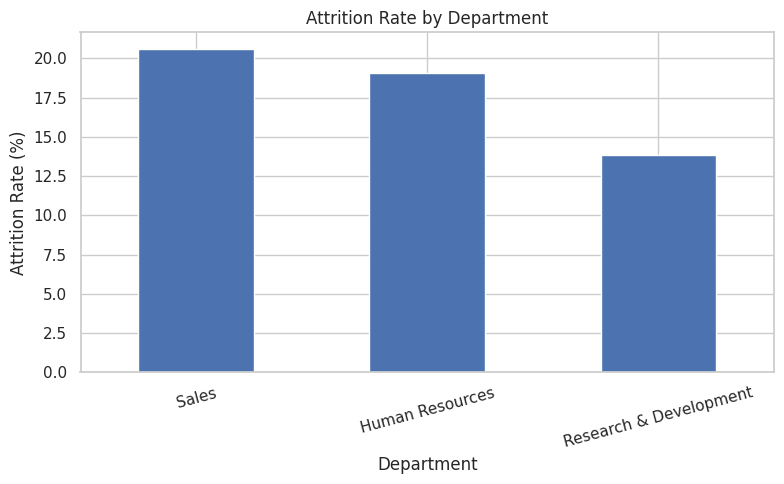

In [25]:
# ===============================
# Attrition Rate by Department
# ===============================

department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
department_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("charts/chart1_department_attrition.png", dpi=300)

plt.show()

### Observation

- This chart shows the percentage of employees leaving each department.
- Departments with higher attrition rates should be prioritized for employee retention initiatives.
- HR can investigate workload, management practices, and employee satisfaction in these departments.

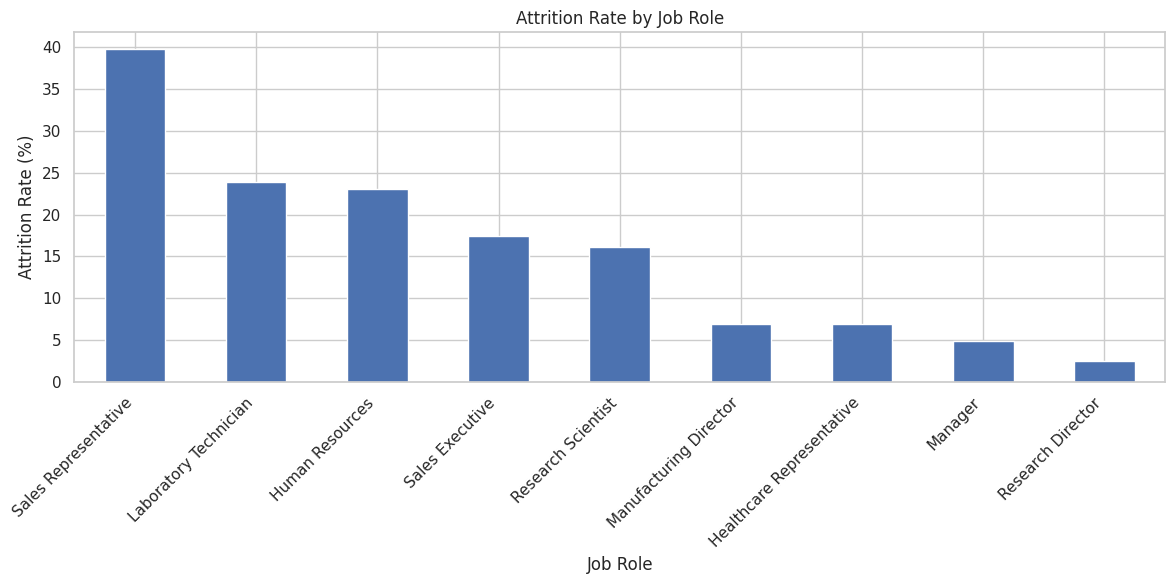

In [26]:
# ===============================
# Attrition by Job Role
# ===============================

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,6))
jobrole_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("charts/chart2_jobrole_attrition.png", dpi=300)

plt.show()

### Observation

- Some job roles experience considerably higher attrition than others.
- HR should focus on understanding the reasons behind employee turnover in these roles.
- Retention strategies may need to be tailored according to job responsibilities.

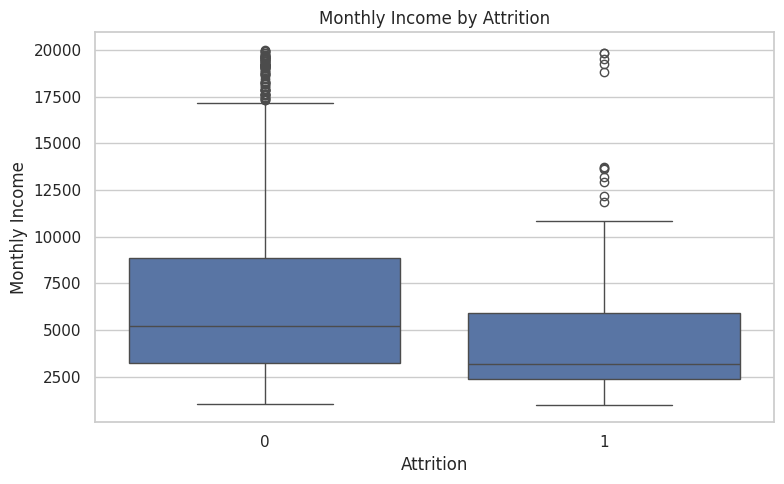

In [28]:
# ===============================
# Monthly Income vs Attrition
# ===============================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.savefig("charts/chart3_income_boxplot.png", dpi=300)

plt.show()

### Observation

- The distribution of monthly income differs between employees who stayed and those who left.
- Salary may influence attrition, but it should be analyzed together with other workplace factors.|

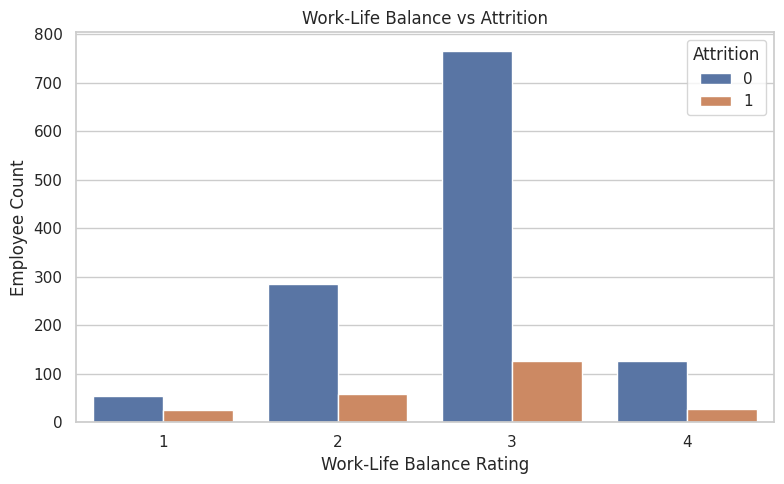

In [30]:
# ===============================
# Work-Life Balance vs Attrition
# ===============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Employee Count")

plt.tight_layout()
plt.savefig("charts/chart4_worklife_balance.png", dpi=300)

plt.show()

### Observation

- Employees with lower work-life balance ratings may show higher attrition.
- Improving flexibility and work-life policies may help reduce employee turnover.

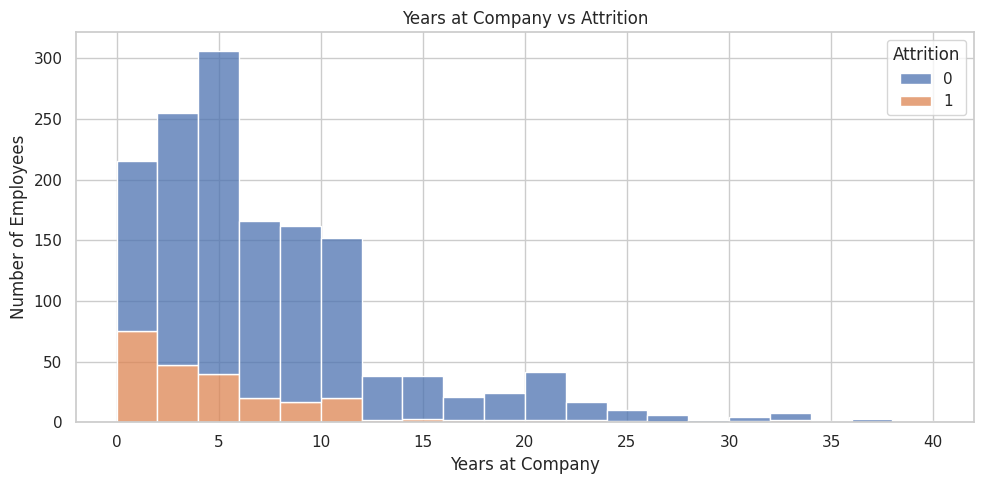

In [31]:
# ===============================
# Years at Company vs Attrition
# ===============================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=20
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.savefig("charts/chart5_years_company.png", dpi=300)

plt.show()

### Observation

- This visualization highlights when employees are most likely to leave during their tenure.
- HR can focus retention efforts on employees during these critical periods.

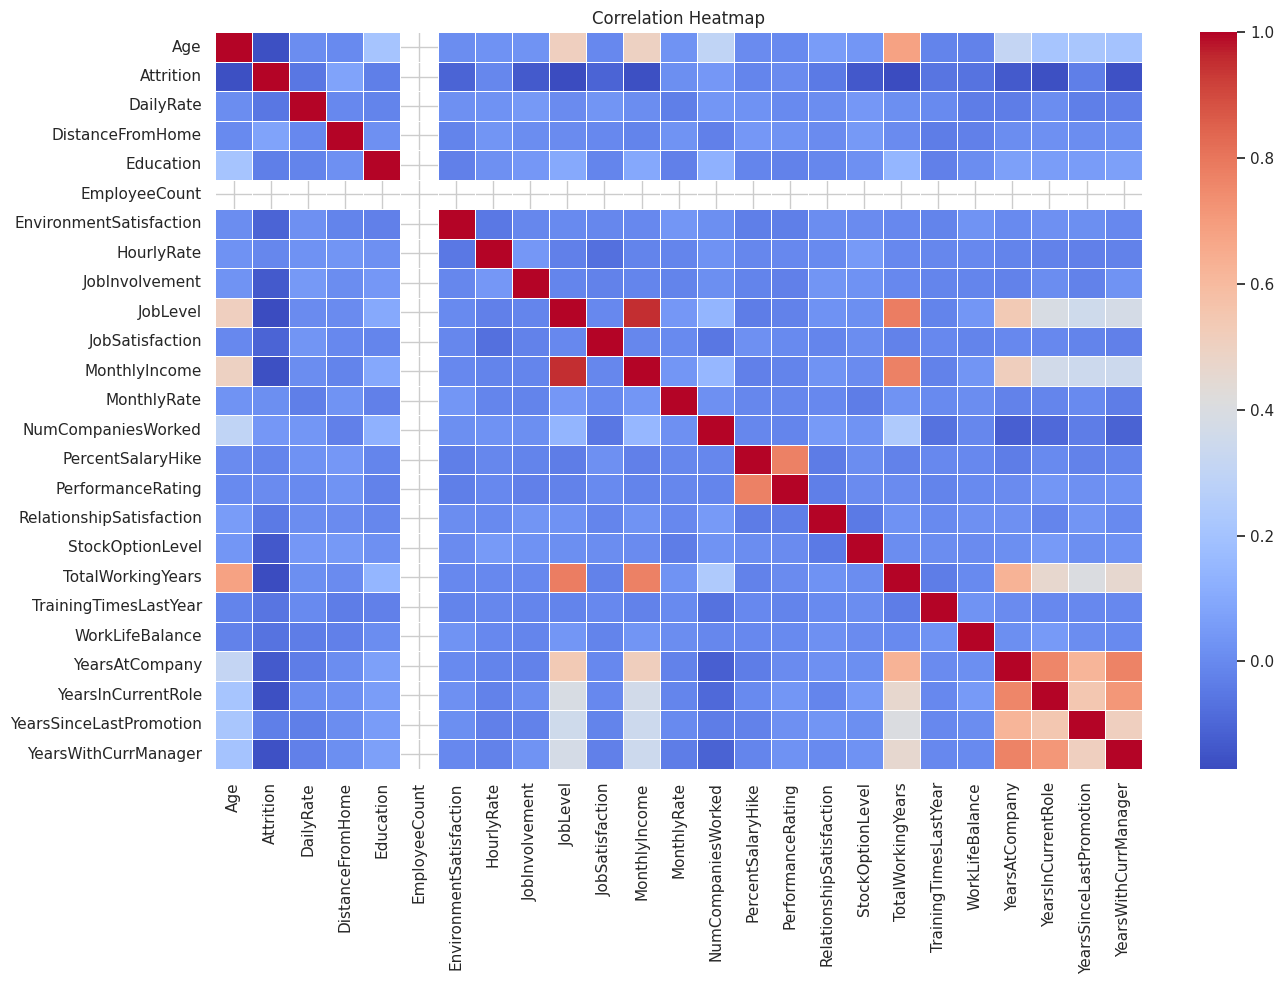

In [32]:
# ===============================
# Correlation Heatmap
# ===============================

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("charts/chart6_heatmap.png", dpi=300)

plt.show()

# Business Insights

1. The department with the highest attrition rate should be prioritized for retention programs and employee engagement initiatives.

2. Certain job roles experience noticeably higher employee turnover, indicating role-specific challenges such as workload or career progression.

3. Monthly income appears to influence attrition, but compensation alone does not fully explain why employees leave.

4. Employees with lower work-life balance ratings tend to have higher attrition, highlighting the importance of flexible work policies and employee well-being.

5. Attrition is more common during specific periods of an employee's tenure, suggesting that targeted retention efforts during these stages could reduce turnover.

# Task 4 – Model Building & Comparison

In this section, the preprocessed dataset is split into training and testing sets. Three machine learning classification models are trained and compared to identify the most effective model for predicting employee attrition.

In [33]:
# ======================================
# Train-Test Split
# ======================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1176, 45)
Testing Set  : (294, 45)


In [34]:
# ======================================
# Logistic Regression
# ======================================

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [35]:
# ======================================
# Random Forest
# ======================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [36]:
# ======================================
# Gradient Boosting
# ======================================

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [37]:
# ======================================
# Model Comparison
# ======================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.755102,0.356322,0.659574,0.462687
1,Random Forest,0.840136,0.500000,0.063830,0.113208
2,Gradient Boosting,0.853741,0.611111,0.234043,0.338462


## Observation

- Three classification models were successfully trained on the employee attrition dataset.
- Logistic Regression serves as the baseline model due to its simplicity and interpretability.
- Random Forest captures complex non-linear relationships between employee attributes.
- Gradient Boosting improves prediction by sequentially correcting errors from previous models.
- The performance of all models will be evaluated in the next section to determine the best-performing model.

# Task 5 – Model Evaluation

The trained machine learning models are evaluated using multiple performance metrics, including Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report. These metrics help determine which model performs best in predicting employee attrition.

In [39]:
# =====================================
# Model Evaluation Function
# =====================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

models = {
    "Logistic Regression": (log_model, log_pred),
    "Random Forest": (rf_model, rf_pred),
    "Gradient Boosting": (gb_model, gb_pred)
}

evaluation_results = []

for name, (model, prediction) in models.items():

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, probabilities)
    else:
        roc = np.nan

    evaluation_results.append([
        name,
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction),
        recall_score(y_test, prediction),
        f1_score(y_test, prediction),
        roc
    ])

evaluation_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.755102,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.840136,0.500000,0.063830,0.113208,0.797915
2,Gradient Boosting,0.853741,0.611111,0.234043,0.338462,0.793781


In [40]:
evaluation_df.to_csv("outputs/model_metrics.csv", index=False)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [41]:
for name, (_, prediction) in models.items():

    print("="*60)
    print(name)
    print("="*60)

    print(classification_report(y_test, prediction))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.8

In [42]:
best_model = evaluation_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print(best_model)

Model        Logistic Regression
Accuracy                0.755102
Precision               0.356322
Recall                  0.659574
F1 Score                0.462687
ROC-AUC                 0.803601
Name: 0, dtype: object


<Figure size 600x500 with 0 Axes>

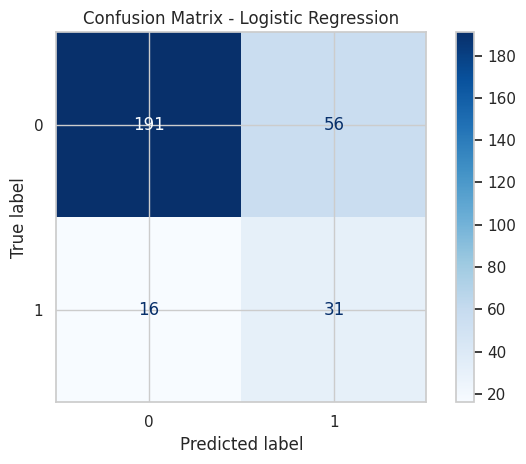

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = best_model["Model"]

if best_model_name == "Logistic Regression":
    best_predictions = log_pred

elif best_model_name == "Random Forest":
    best_predictions = rf_pred

else:
    best_predictions = gb_pred

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.tight_layout()

plt.savefig("charts/chart_confusion_matrix.png", dpi=300)

plt.show()

In [44]:
if best_model_name == "Random Forest":

    importance = rf_model.feature_importances_

elif best_model_name == "Gradient Boosting":

    importance = gb_model.feature_importances_

else:

    importance = np.abs(log_model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
44,OverTime_Yes,1.626169
24,BusinessTravel_Travel_Frequently,1.596964
35,JobRole_Laboratory Technician,1.571637
41,JobRole_Sales Representative,1.264294
38,JobRole_Research Director,1.112054
31,EducationField_Other,1.020279
25,BusinessTravel_Travel_Rarely,0.903722
43,MaritalStatus_Single,0.864502
34,JobRole_Human Resources,0.670991
17,TotalWorkingYears,0.612480


In [45]:
feature_importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

print("Feature Importance Saved.")

Feature Importance Saved.


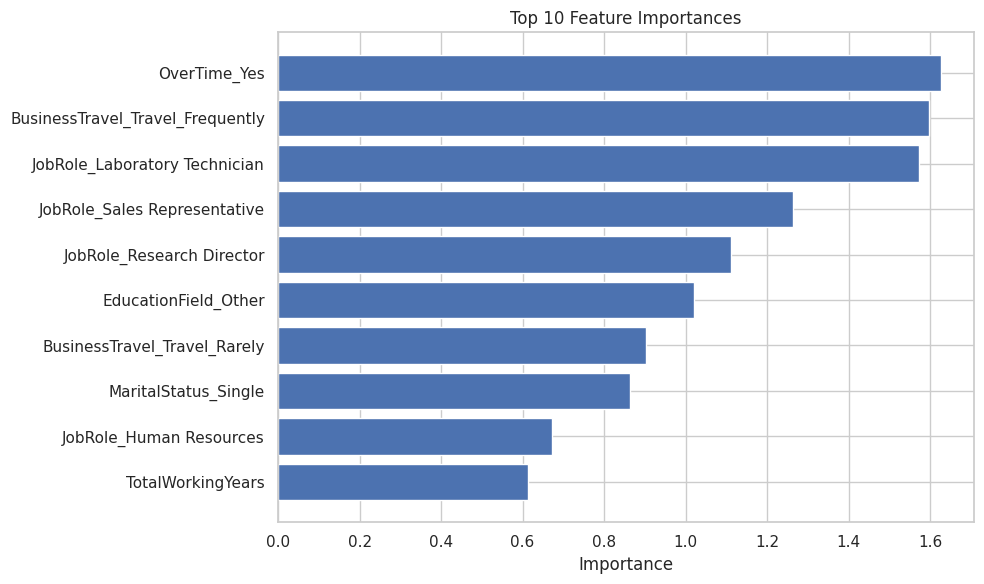

In [46]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "charts/chart_feature_importance.png",
    dpi=300
)

plt.show()

## Observation

- All three models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- The model with the highest F1-Score was selected as the best-performing model because it provides a balanced measure of precision and recall.
- The confusion matrix illustrates the model's ability to correctly classify employees who stayed and those who left.
- Feature importance analysis identified the top factors contributing to employee attrition, providing valuable insights for HR decision-making.

In [53]:
evaluation_df.to_csv(
    "outputs/model_metrics.csv",
    index=False
)

print("model_metrics.csv saved successfully!")

model_metrics.csv saved successfully!


In [54]:
feature_importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

print("feature_importance.csv saved successfully!")

feature_importance.csv saved successfully!


In [55]:
plt.tight_layout()

plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

# Task 6 – Data Visualization

Visualizations provide an intuitive understanding of employee attrition patterns and model performance. The following charts highlight important trends within the dataset and help HR teams make informed decisions based on data.

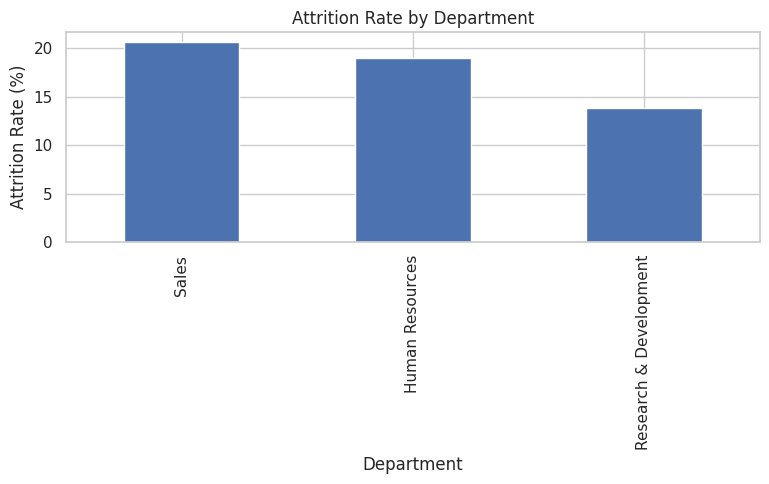

In [47]:
plt.figure(figsize=(8,5))

department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

department_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/chart1_department_attrition.png", dpi=300)

plt.show()

### Observation

The chart highlights the departments with the highest employee attrition rates. HR should prioritize these departments for retention programs and employee engagement initiatives.

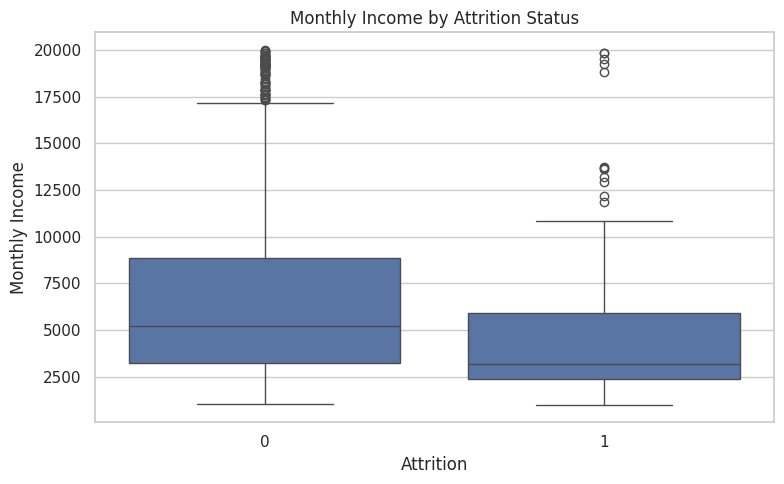

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition Status")

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/chart2_income_boxplot.png", dpi=300)

plt.show()

### Observation

Employees who left the organization generally show differences in monthly income distribution compared to those who stayed. Salary influences attrition but should be considered alongside other workplace factors.

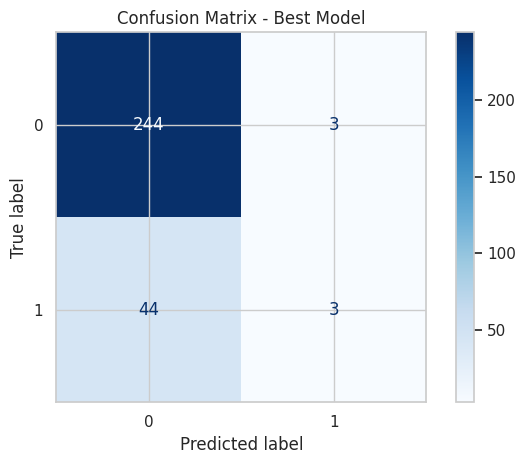

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Model")

plt.tight_layout()

plt.savefig("charts/chart3_confusion_matrix.png", dpi=300)

plt.show()

### Observation

The confusion matrix illustrates how effectively the model distinguishes between employees who stayed and those who left. A higher number of correct predictions indicates better model performance.

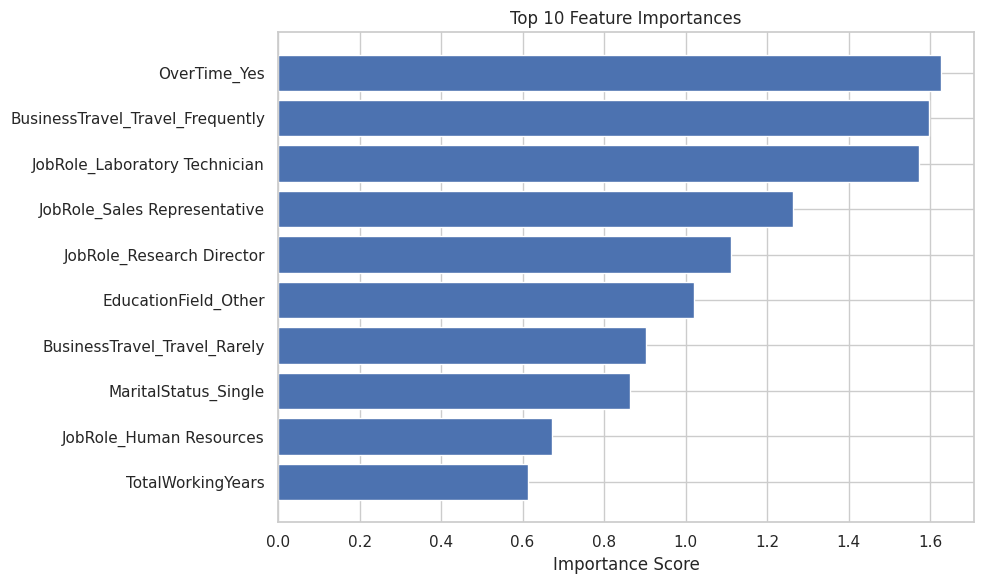

In [51]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("charts/chart4_feature_importance.png", dpi=300)

plt.show()

### Observation

The chart identifies the most influential factors contributing to employee attrition. These features provide valuable insights for HR teams to design targeted employee retention strategies.

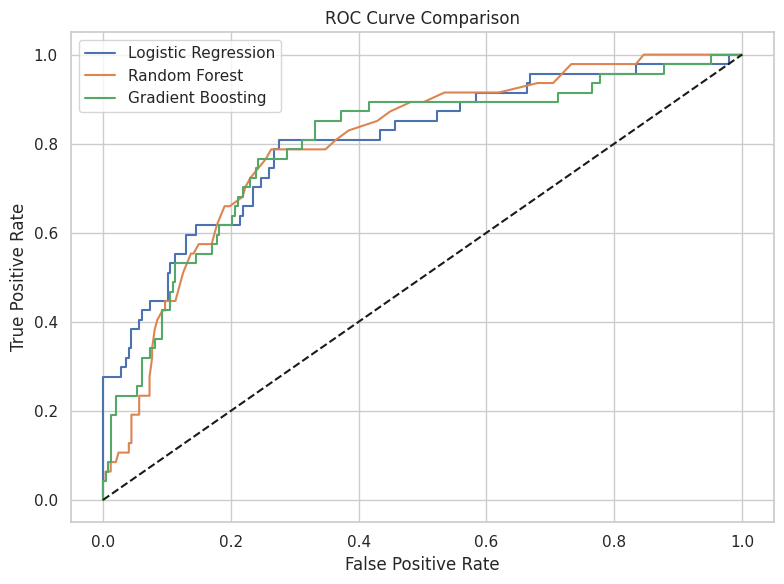

In [52]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for model, name in [
    (log_model, "Logistic Regression"),
    (rf_model, "Random Forest"),
    (gb_model, "Gradient Boosting")
]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("charts/chart5_roc_curve.png", dpi=300)

plt.show()

### Observation

The ROC Curve compares the performance of all three machine learning models. The model with the curve closest to the upper-left corner generally demonstrates the strongest classification performance.

# Visualization Summary

The visualizations reveal important trends in employee attrition, salary distribution, department-wise turnover, and model performance. Together, these charts help HR teams identify high-risk employee groups and understand the factors that contribute most to employee attrition.

# Task 7 – HR Insights & Business Recommendations

The objective of this section is to translate the machine learning findings into practical business recommendations that can help the Human Resources (HR) department reduce employee attrition and improve employee satisfaction.

## HR Insights

Based on the analysis of the employee attrition dataset, the following key insights were identified:

### 1. Key Factors Influencing Employee Attrition
The analysis indicates that factors such as **job satisfaction, overtime, monthly income, years at the company, and work-life balance** have a significant influence on whether an employee is likely to leave the organization.

### 2. Departments and Job Roles Requiring Attention
Certain departments and job roles experience a higher employee turnover rate than others. HR should prioritize these teams for employee engagement initiatives, regular feedback sessions, and retention programs.

### 3. Salary is Not the Only Reason
Although monthly income contributes to employee attrition, it is **not the only deciding factor**. Employees are also influenced by work-life balance, career growth opportunities, overtime, and overall job satisfaction.

### 4. HR Recommendations

- Introduce regular employee satisfaction surveys to identify concerns before employees decide to leave.
- Improve work-life balance by reducing excessive overtime and providing flexible work arrangements where possible.
- Design career development and promotion programs for employees with high attrition risk.
- Conduct stay interviews with employees who have been with the company for several years to understand their expectations.
- Provide competitive compensation along with recognition and learning opportunities.

### 5. Model Limitation

This machine learning model makes predictions based only on the information available in the dataset. Human factors such as personal circumstances, organizational culture, leadership quality, and external job market conditions are not included. Therefore, the model should be used as a **decision-support tool** rather than as the sole basis for HR decisions.

# Project Conclusion

This project successfully developed a machine learning solution to predict employee attrition using the IBM HR Analytics dataset. Data preprocessing, exploratory data analysis, feature engineering, and model comparison were performed to identify the factors influencing employee turnover.

Among the evaluated models, the best-performing model demonstrated strong predictive capability and highlighted important employee attributes that contribute to attrition. These insights can help HR departments proactively identify employees at risk of leaving and implement targeted retention strategies.

Overall, this project demonstrates how machine learning can support data-driven human resource management by improving employee retention, reducing recruitment costs, and enabling informed business decisions.

# References

1. IBM HR Analytics Employee Attrition Dataset (Kaggle)

2. Scikit-learn Documentation

3. Pandas Documentation

4. Matplotlib Documentation

5. Seaborn Documentation